# Phase 3: Predictive Modeling
## Jeddah Real Estate Price Prediction

This notebook:
1. Prepares features for modeling
2. Trains Linear Regression, Random Forest, and Gradient Boosting
3. Evaluates models with 5-fold cross-validation
4. Compares performance using MAE, MSE, Median Squared Error, and R-squared
5. Analyzes feature importance
6. Saves the best model for deployment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import os
import warnings

from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
%matplotlib inline

In [2]:
def median_squared_error(y_true, y_pred):
    """Median Squared Error - robust alternative to MSE, less sensitive to outliers."""
    return float(np.median((y_true - y_pred) ** 2))

def evaluate_model(y_true, y_pred):
    """Compute all evaluation metrics."""
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
        'MedSE': median_squared_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }

## 1. Load and Prepare Data

In [3]:
df = pd.read_csv('data/cleaned_data.csv', encoding='utf-8-sig')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: (6626, 14)
Columns: ['district', 'furnished', 'ac', 'kitchen', 'age', 'street_width', 'area', 'wc', 'livings', 'beds', 'price', 'year', 'month', 'total_rooms']


,district,furnished,ac,kitchen,age,street_width,area,wc,livings,beds,price,year,month,total_rooms
0,حي الرويس,1,1,1,0,13,170,3,1,2,100000,2021,4,6
1,حي العزيزية,1,1,1,3,5,20,2,1,2,38000,2021,6,5
2,حي النهضة,1,1,1,3,5,25,1,1,2,45000,2021,8,4
3,حي الزمرد,1,1,1,20,5,170,3,1,3,65000,2021,8,7
4,حي السلامة,1,1,1,0,5,20,1,1,2,42000,2021,11,4


In [4]:
# Define feature groups
target = 'price'
categorical_features = ['district']
numeric_features = ['age', 'street_width', 'area', 'wc', 'livings', 'beds',
                    'year', 'month', 'total_rooms']
binary_features = ['furnished', 'ac', 'kitchen']

# Separate features and target
X = df.drop(columns=[target])
y = df[target]

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 5300 samples
Test set: 1326 samples


In [5]:
# Build preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('num', StandardScaler(), numeric_features),
        ('bin', 'passthrough', binary_features)
    ]
)

print("Preprocessor configured:")
print(f"  Categorical (OneHotEncoded): {categorical_features}")
print(f"  Numeric (StandardScaled): {numeric_features}")
print(f"  Binary (passthrough): {binary_features}")

Preprocessor configured:
  Categorical (OneHotEncoded): ['district']
  Numeric (StandardScaled): ['age', 'street_width', 'area', 'wc', 'livings', 'beds', 'year', 'month', 'total_rooms']
  Binary (passthrough): ['furnished', 'ac', 'kitchen']


## 2. Define Models

In [6]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=15, min_samples_leaf=5,
        random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        random_state=42
    )
}

# Wrap each in a pipeline with the preprocessor
pipelines = {}
for name, model in models.items():
    pipelines[name] = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    print(f"Pipeline created: {name}")

Pipeline created: Linear Regression
Pipeline created: Random Forest
Pipeline created: Gradient Boosting


## 3. Five-Fold Cross-Validation

In [7]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {name: {'MAE': [], 'MSE': [], 'MedSE': [], 'R2': []} for name in pipelines}

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), 1):
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    for name, pipe in pipelines.items():
        pipe.fit(X_fold_train, y_fold_train)
        y_pred = pipe.predict(X_fold_val)
        metrics = evaluate_model(y_fold_val.values, y_pred)
        for metric_name, value in metrics.items():
            cv_results[name][metric_name].append(value)

    print(f"Fold {fold}/5 complete")

print("\nCross-validation complete!")

Fold 1/5 complete


Fold 2/5 complete


Fold 3/5 complete


Fold 4/5 complete


Fold 5/5 complete

Cross-validation complete!


In [8]:
# Cross-validation results summary
cv_summary = []
for name in pipelines:
    row = {'Model': name}
    for metric in ['MAE', 'MSE', 'MedSE', 'R2']:
        values = cv_results[name][metric]
        row[f'{metric} (mean)'] = np.mean(values)
        row[f'{metric} (std)'] = np.std(values)
    cv_summary.append(row)

cv_df = pd.DataFrame(cv_summary).set_index('Model')
print("5-Fold Cross-Validation Results:")
cv_df

5-Fold Cross-Validation Results:


,MAE (mean),MAE (std),MSE (mean),MSE (std),MedSE (mean),MedSE (std),R2 (mean),R2 (std)
Model,,,,,,,,
Linear Regression,7492.158359,398.039244,2.915927e+08,1.619339e+08,2.241079e+07,7.297854e+05,0.459515,0.085427
Random Forest,7305.511360,472.905315,2.945481e+08,1.619540e+08,1.742907e+07,1.000560e+06,0.458592,0.089275
Gradient Boosting,6519.305984,370.350097,2.875099e+08,1.068167e+08,1.233667e+07,8.067197e+05,0.400348,0.160103


## 4. Final Evaluation on Test Set

In [9]:
# Retrain on full training set and evaluate on test set
test_results = {}
predictions = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    test_results[name] = evaluate_model(y_test.values, y_pred)
    predictions[name] = y_pred

# Baseline: mean predictor
baseline_pred = np.full_like(y_test.values, y_train.mean(), dtype=float)
test_results['Baseline (Mean)'] = evaluate_model(y_test.values, baseline_pred)

# Display results
test_df = pd.DataFrame(test_results).T
test_df.index.name = 'Model'
print("Test Set Results:")
test_df

Test Set Results:


,MAE,MSE,MedSE,R2
Model,,,,
Linear Regression,7363.604459,3.985553e+08,2.118530e+07,0.276153
Random Forest,7229.049796,3.985366e+08,1.573681e+07,0.276187
Gradient Boosting,6321.121471,3.648488e+08,1.207072e+07,0.337370
Baseline (Mean),11941.475597,5.506086e+08,8.693449e+07,-0.000003


## 5. Model Comparison Visualizations

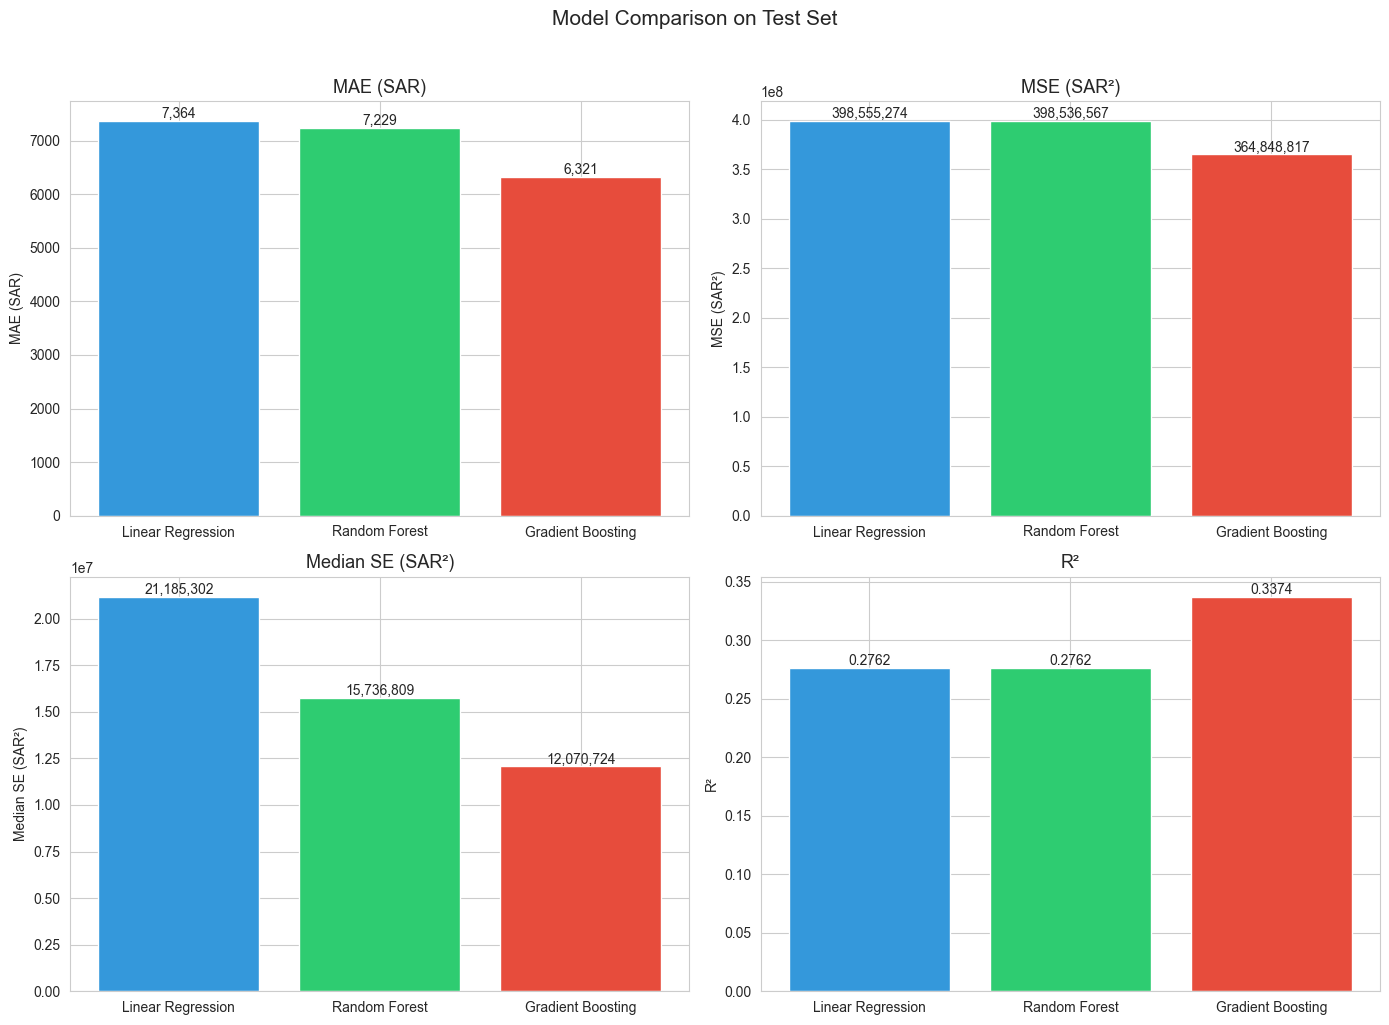

In [10]:
# Bar chart comparing models across all metrics
model_names = ['Linear Regression', 'Random Forest', 'Gradient Boosting']
metrics_to_plot = ['MAE', 'MSE', 'MedSE', 'R2']
metric_labels = ['MAE (SAR)', 'MSE (SAR\u00b2)', 'Median SE (SAR\u00b2)', 'R\u00b2']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (metric, label) in enumerate(zip(metrics_to_plot, metric_labels)):
    ax = axes[i // 2][i % 2]
    values = [test_results[name][metric] for name in model_names]
    colors = ['#3498db', '#2ecc71', '#e74c3c']
    bars = ax.bar(model_names, values, color=colors)
    ax.set_title(label, fontsize=13)
    ax.set_ylabel(label)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:,.0f}' if metric != 'R2' else f'{val:.4f}',
                ha='center', va='bottom', fontsize=10)

plt.suptitle('Model Comparison on Test Set', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

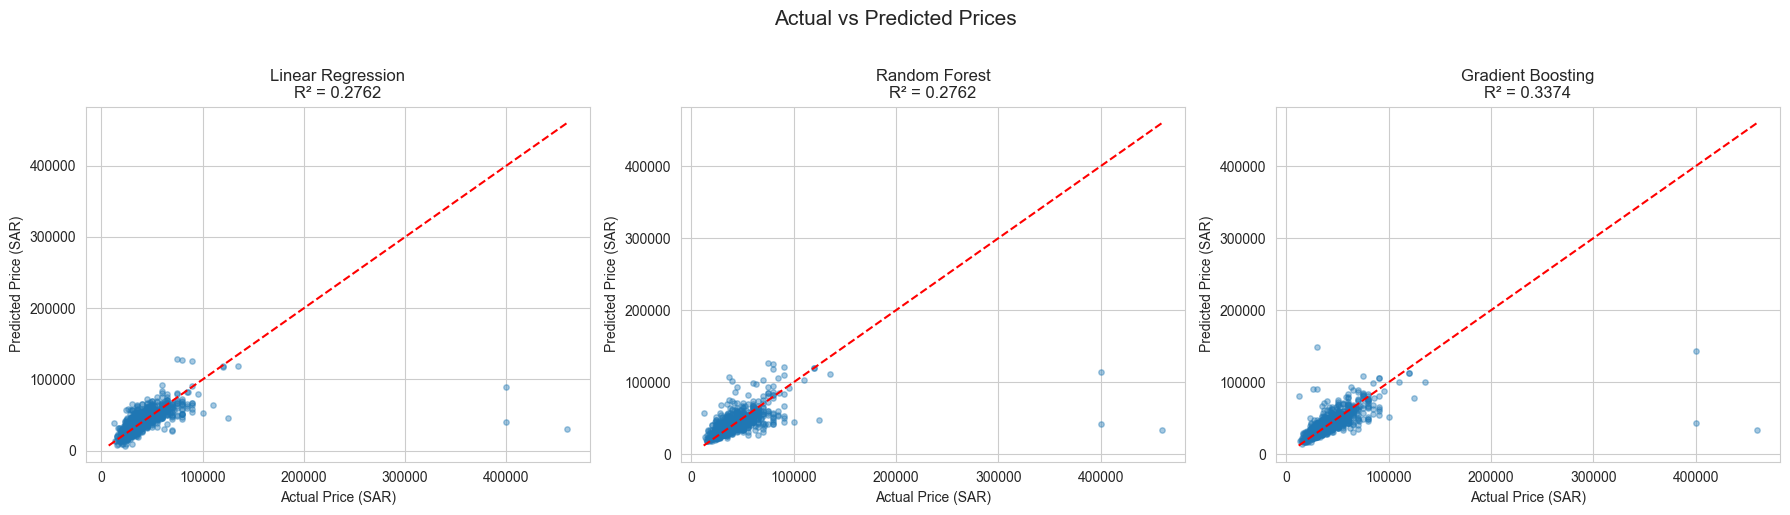

In [11]:
# Actual vs Predicted scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, name in enumerate(model_names):
    ax = axes[i]
    ax.scatter(y_test, predictions[name], alpha=0.4, s=15)
    # Reference line (perfect prediction)
    min_val = min(y_test.min(), predictions[name].min())
    max_val = max(y_test.max(), predictions[name].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5)
    ax.set_title(f'{name}\nR\u00b2 = {test_results[name]["R2"]:.4f}')
    ax.set_xlabel('Actual Price (SAR)')
    ax.set_ylabel('Predicted Price (SAR)')

plt.suptitle('Actual vs Predicted Prices', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 6. Feature Importance

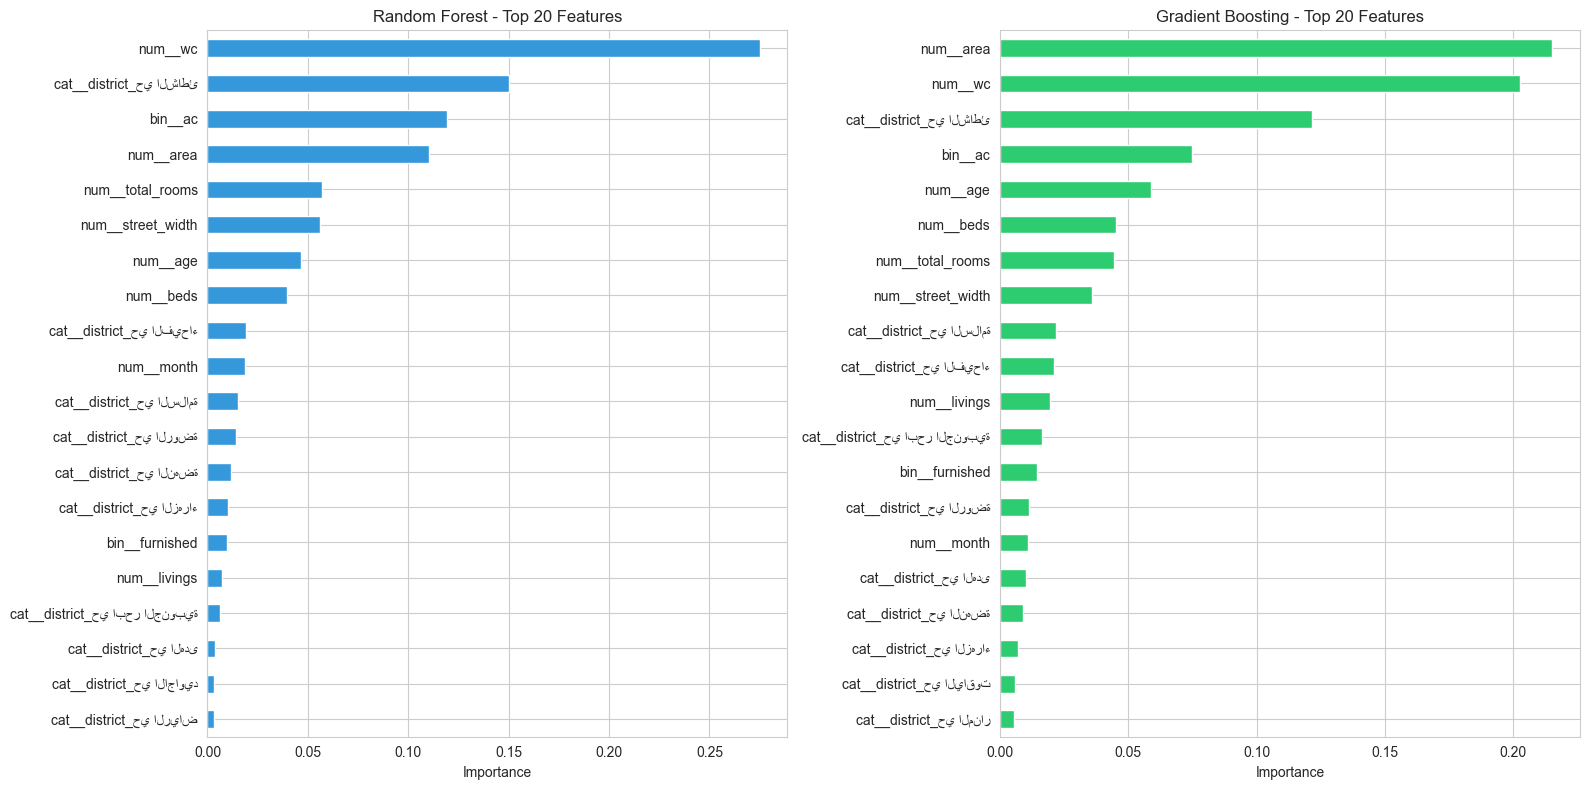

In [12]:
# Get feature names from the preprocessor
feature_names = pipelines['Random Forest']['preprocessor'].get_feature_names_out()

# Feature importance for Random Forest and Gradient Boosting
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for i, name in enumerate(['Random Forest', 'Gradient Boosting']):
    importances = pipelines[name]['model'].feature_importances_
    feat_imp = pd.Series(importances, index=feature_names)
    top20 = feat_imp.nlargest(20)

    top20.sort_values().plot(kind='barh', ax=axes[i], color=['#3498db', '#2ecc71'][i])
    axes[i].set_title(f'{name} - Top 20 Features')
    axes[i].set_xlabel('Importance')

plt.tight_layout()
plt.show()

## 7. Residual Analysis (Best Model)

Best model: Gradient Boosting (MAE = 6,321 SAR)


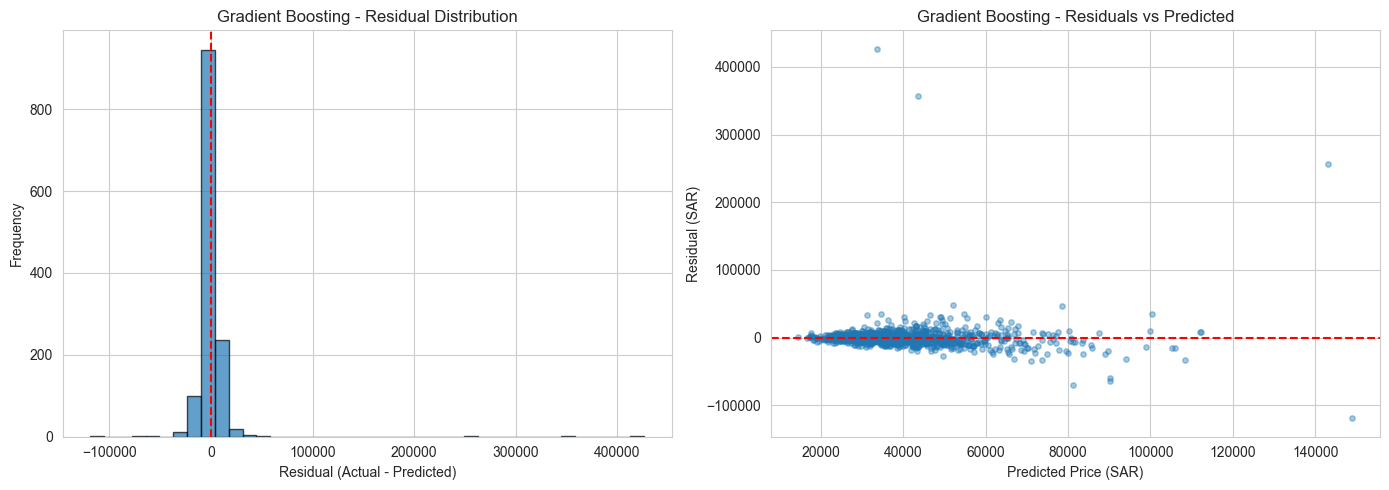

In [13]:
# Identify best model by lowest MAE
best_name = min(
    [n for n in model_names],
    key=lambda n: test_results[n]['MAE']
)
print(f"Best model: {best_name} (MAE = {test_results[best_name]['MAE']:,.0f} SAR)")

best_pred = predictions[best_name]
residuals = y_test.values - best_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual distribution
axes[0].hist(residuals, bins=40, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--')
axes[0].set_title(f'{best_name} - Residual Distribution')
axes[0].set_xlabel('Residual (Actual - Predicted)')
axes[0].set_ylabel('Frequency')

# Residuals vs Predicted
axes[1].scatter(best_pred, residuals, alpha=0.4, s=15)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title(f'{best_name} - Residuals vs Predicted')
axes[1].set_xlabel('Predicted Price (SAR)')
axes[1].set_ylabel('Residual (SAR)')

plt.tight_layout()
plt.show()

## 8. Save Best Model

In [14]:
os.makedirs('models', exist_ok=True)

# Save the best pipeline (preprocessor + model together)
best_pipeline = pipelines[best_name]
best_pipeline.fit(X_train, y_train)  # ensure trained on full training set
joblib.dump(best_pipeline, 'models/best_model.joblib')
print(f"Saved best model: {best_name}")

# Save feature column order for the Streamlit app
joblib.dump(list(X.columns), 'models/feature_columns.joblib')

# Save district list for UI dropdown
district_list = sorted(df['district'].unique().tolist())
with open('models/district_list.json', 'w', encoding='utf-8') as f:
    json.dump(district_list, f, ensure_ascii=False, indent=2)

print(f"Saved {len(district_list)} districts to models/district_list.json")
print(f"Saved feature columns: {list(X.columns)}")
print("\nModel training and evaluation complete!")

Saved best model: Gradient Boosting
Saved 66 districts to models/district_list.json
Saved feature columns: ['district', 'furnished', 'ac', 'kitchen', 'age', 'street_width', 'area', 'wc', 'livings', 'beds', 'year', 'month', 'total_rooms']

Model training and evaluation complete!
